# Data Download and Preprocessing

In this notebook, we will download the vector data and contextual layers needed for this project. 
See this spreadsheet for the list of data sources and the corresponding links: [Data Sources](
https://docs.google.com/spreadsheets/d/1XSG0xyoWcLVuGSY2-Mrfalyf6tN--PPOkQWVxDr6XfM/edit?usp=sharing
).
We will also preprocess the data to make it ready for analysis.

## Table of Contents
### [Data Download](#data-download)
- **[Sahel region](#sahel)**
- **[HydroBASINS](#hydro)**
- **[Country Boundaries (OSM)](#country-boundaries)**

## Setup

### Library import


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
from processing.config import HYDROBASINS_AFRICA_URL
from processing.data.storage.s3 import upload_file_to_s3
from processing.pipelines.countries import download_country_data, process_country_data
from processing.pipelines.hydrobasins import (
    download_hydrobasins_africa,
    filter_hydrobasins_by_sahel,
    process_hydrobasins_data,
)
from processing.pipelines.sahel import download_sahel_boundary, process_sahel_data

<a id='sahel'></a>
### Sahel Region ([source](https://drive.google.com/file/d/10I6Z6k_5laK70n1BpnWC_BWAHR8IbF2g/view?usp=drive_link))


**Download data**

In [4]:
directory = Path("../data/raw/")
file_name = "sahel_boundary.gpkg"
file_id = "10I6Z6k_5laK70n1BpnWC_BWAHR8IbF2g"
gdf = download_sahel_boundary(directory, file_name, file_id)
gdf.head()

📥 Downloading Sahel boundary data from Google Drive...

✅ Downloaded Sahel boundary data to: ../data/raw/sahel_boundary.gpkg

,Id,geometry
0,613021,"MULTIPOLYGON (((42.94782 10.99465, 42.97027 10..."


**Data processing**

In [5]:
sahel = process_sahel_data(gdf)
sahel.head()

🔧 Processing Sahel boundary data...

✅ Processed 1 features in Sahel boundary data

,Id,name,bbox,geometry
0,613021,Sahel Boundary,"{'bbox': [-18.46394608680282, -4.9003250008774...","MULTIPOLYGON (((42.94782 10.99465, 42.97027 10..."


**Display layer**

<Axes: >

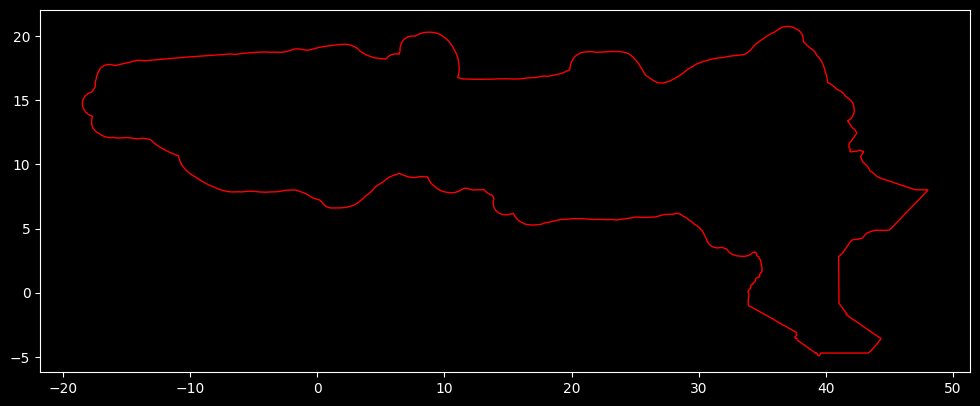

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

sahel.plot(ax=ax, color="none", edgecolor="red")

**Save data**

In [6]:
gdf.to_file("../data/processed/sahel_boundary.geojson", driver="GeoJSON")

**Upload data to S3**

In [ ]:
local_path = "../data/processed/sahel_boundary.geojson"
object_key = "Wetlands/data/processed/sahel_boundary.geojson"

upload_file_to_s3(local_path, object_key)

<a id='hydro'></a>
### HydroBASINS ([source](https://www.hydrosheds.org/products/hydrobasins))

**License**

The HydroBASINS database is freely available for scientific, educational and commercial use. The data are distributed under the same license agreement as the HydroSHEDS core products, which is included in the [HydroSHEDS Technical Documentation](https://data.hydrosheds.org/file/technical-documentation/HydroSHEDS_TechDoc_v1_4.pdf). For all regulations regarding license grants, copyright, redistribution restrictions, required attributions, disclaimer of warranty, indemnification, liability, and waiver of damages, please refer to the license agreement.

By downloading and using the data the user agrees to the terms and conditions of this license.

**References**
Lehner, B., Grill G. (2013). Global river hydrography and network routing: baseline data and new approaches to study the world’s large river systems. Hydrological Processes, 27(15): 2171–2186. https://doi.org/10.1002/hyp.9740

**Download data**

From FAO Map Catalog: [Hydrological basins in Africa](https://data.apps.fao.org/map/catalog/srv/eng/catalog.search#/metadata/e54e2014-d23b-402b-8e73-c827628d17f4)

In [2]:
url = HYDROBASINS_AFRICA_URL
directory = Path("../data/raw/")
gdf = download_hydrobasins_africa(directory, url)
gdf.head()

📥 Downloading HydroBASINS data for Africa...

✅ Downloaded and unzipped to ../data/raw/hydrobasins_africa

,SUB_BAS,TO_BAS,MAJ_BAS,SUB_NAME,MAJ_NAME,SUB_AREA,MAJ_AREA,LEGEND,geometry
0,90002,-888,7009,Borkou,Lake Chad,1179610,2461890,9,"POLYGON ((15.525 13.52083, 15.52917 13.52083, ..."
1,30003,30272,7003,White Nile 5,Nile,97222,3074955,3,"MULTIPOLYGON (((32.24167 6.1625, 32.25 6.1625,..."
2,90008,-888,7009,Dillia,Lake Chad,162385,2461890,9,"POLYGON ((12.02917 16.12083, 12.03333 16.12083..."
3,30029,30297,7003,Lake Victoria,Nile,69200,3074955,3,"POLYGON ((33.26667 0.375, 33.26667 0.37083, 33..."
4,100030,-888,7010,Lake Rukwa,Rift Valley,3443,638878,10,"POLYGON ((31.95 -7.55, 31.95 -7.55833, 31.9583..."


**Data processing**

In [3]:
# Merge the sub-basins into major basins
gdf = process_hydrobasins_data(gdf)
# Filter the sub-basins to only include those that are part of Sahel region
sahel_boundary_path = Path("../data/raw/Sahel-zone - extended - dissolved.gpkg")
gdf = filter_hydrobasins_by_sahel(gdf, sahel_boundary_path)

gdf.head()

🔄 Processing HydroBASINS data...

🗺️  Filtering basins for Sahel region...

✅ Filtered to 245 basins in Sahel region

,maj_bas,maj_name,maj_area,level,sub_bas,sub_name,sub_area,geometry
0,7018,"Africa, East Central Coast",1041192,1,NaN,NaN,NaN,"MULTIPOLYGON (((38.87083 -17.22917, 38.8875 -1..."
1,7018,"Africa, East Central Coast",1041192,2,180371.0,Kenyan north east coast,49241.0,"MULTIPOLYGON (((40.8375 -2.43333, 40.8375 -2.4..."
2,7018,"Africa, East Central Coast",1041192,2,180372.0,Tana,96296.0,"POLYGON ((38.28333 0.4875, 38.28333 0.48333, 3..."
3,7018,"Africa, East Central Coast",1041192,2,180374.0,Galana,46624.0,"POLYGON ((36.59167 -0.84167, 36.59167 -0.85, 3..."
4,7018,"Africa, East Central Coast",1041192,2,180376.0,Pangani,51206.0,"POLYGON ((37.2125 -3.04167, 37.2125 -3.05, 37...."


**Display layer**

<Axes: >

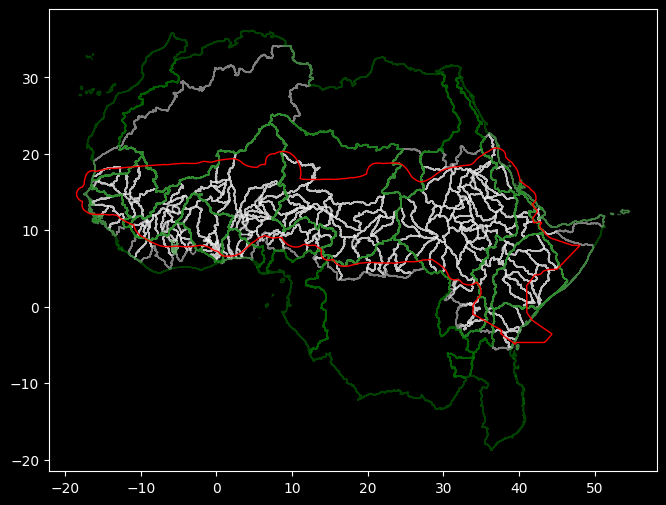

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

hydro_1 = gdf[gdf["level"] == 1]
hydro_2 = gdf[gdf["level"] == 2]

hydro_2.plot(ax=ax, color="none", edgecolor="white", alpha=0.5)
hydro_1.plot(ax=ax, color="none", edgecolor="green", alpha=0.5)
sahel.plot(ax=ax, color="none", edgecolor="red")

**Save data**

In [ ]:
gdf.to_file("../data/processed/hydrobasins_sahel.geojson", driver="GeoJSON")

**Upload data to S3**

In [5]:
local_path = "../data/processed/hydrobasins_sahel.geojson"
object_key = "Wetlands/data/processed/hydrobasins_sahel.geojson"

upload_file_to_s3(local_path, object_key)

✅ Uploaded ../data/processed/hydrobasins_sahel.geojson → 
s3://vizz-science-team/Wetlands/data/processed/hydrobasins_sahel.geojson

<a id='country-boundaries'></a>
### Country Boundaries (OSM) ([source](https://osm-boundaries.com/))


**Read data**

In [11]:
DEFAULT_SAHEL_COUNTRIES = [
    "Senegal",
    "Mauritania",
    "Mali",
    "Burkina Faso",
    "Niger",
    "Chad",
    "Sudan",
    "Nigeria",
    "Eritrea",
    "Cameroon",
    "Gambia",
    "Guinea",
    "South Sudan",
    "Ethiopia",
    "Kenya",
    "Côte d'Ivoire",
    "Ghana",
    "Togo",
    "Benin",
    "Guinea-Bissau",
    "Central African Republic",
    "Uganda",
]

gdf = download_country_data(DEFAULT_SAHEL_COUNTRIES)
gdf.head()

📥 Downloading country data from OSM for 22 countries...
Successfully got data for Senegal
Successfully got data for Mauritania
Successfully got data for Mali
Successfully got data for Burkina Faso
Successfully got data for Niger
Successfully got data for Chad
Successfully got data for Sudan
Successfully got data for Nigeria
Successfully got data for Eritrea
Successfully got data for Cameroon
Successfully got data for Gambia
Successfully got data for Guinea
Successfully got data for South Sudan
Successfully got data for Ethiopia
Successfully got data for Kenya
Successfully got data for Côte d'Ivoire
Successfully got data for Ghana
Successfully got data for Togo
Successfully got data for Benin
Successfully got data for Guinea-Bissau
Successfully got data for Central African Republic
Successfully got data for Uganda
✅ Downloaded data for 22 countries


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name,country_name
0,"POLYGON ((-17.74987 14.74329, -17.74984 14.741...",-17.749869,12.240266,-11.345950,16.691971,274719798,relation,192775,14.475061,-14.452961,boundary,administrative,4,0.753022,country,Senegal,Senegal,Senegal
1,"POLYGON ((-17.2381 20.66622, -17.23676 20.6625...",-17.238096,14.720991,-4.833334,27.314942,274302044,relation,192763,20.254038,-9.239926,boundary,administrative,4,0.709675,country,Mauritania,Mauritania,Mauritania
2,"POLYGON ((-12.24028 14.76472, -12.23971 14.762...",-12.240284,10.147811,4.267383,25.001084,275502024,relation,192785,16.370036,-2.290024,boundary,administrative,4,0.736002,country,Mali,Mali,Mali
3,"POLYGON ((-5.51321 10.43079, -5.51319 10.43066...",-5.513207,9.410472,2.408972,15.084004,275291535,relation,192783,12.075308,-1.688031,boundary,administrative,4,0.729269,country,Burkina Faso,Burkina Faso,Burkina Faso
4,"POLYGON ((0.16897 14.52207, 0.17333 14.50556, ...",0.168965,11.693607,15.996667,23.517178,47248473,relation,192786,17.735621,9.323843,boundary,administrative,4,0.710333,country,Niger,Niger,Niger


**Data processing**

In [12]:
gdf = process_country_data(gdf)
gdf.head()

🔄 Processing country data...
✅ Processed 22 countries


,name,bbox,ISO3,geometry
0,Benin,"{'bbox': [0.776667, 6.0398696, 3.8451454, 12.4...",BEN,"POLYGON ((0.77667 10.37667, 0.7922 10.36589, 0..."
1,Burkina Faso,"{'bbox': [-5.513207, 9.4104718, 2.4089717, 15....",BFA,"POLYGON ((-5.51321 10.43079, -5.51319 10.43066..."
2,Cameroon,"{'bbox': [8.3822176, 1.6517945, 16.1911011, 13...",CMR,"POLYGON ((8.38222 4.34753, 8.39136 4.34017, 8...."
3,Central African Republic,"{'bbox': [14.4148457, 2.222929, 27.4665499, 11...",CAF,"POLYGON ((14.41485 6.04235, 14.41494 6.042, 14..."
4,Chad,"{'bbox': [13.47348, 7.44107, 24.0, 23.4507957]}",TCD,"POLYGON ((13.47348 14.44282, 13.47622 14.40789..."


**Display layer**

<Axes: >

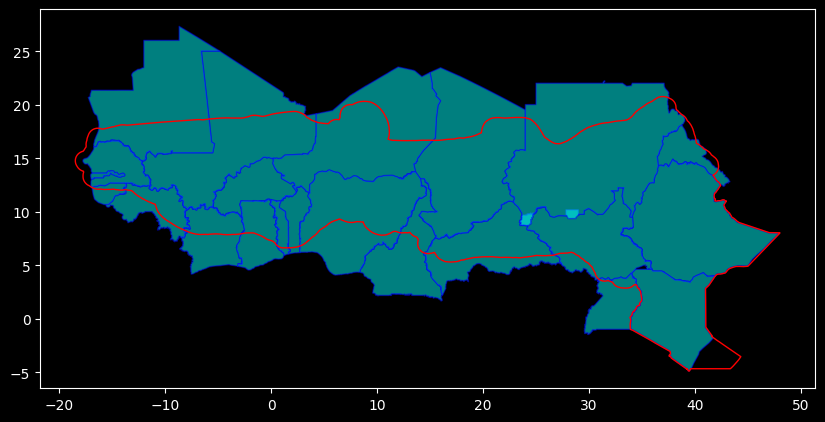

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

gdf.plot(ax=ax, color="cyan", edgecolor="blue", alpha=0.5)
sahel.plot(ax=ax, color="none", edgecolor="red")

**Save data**

In [ ]:
gdf.to_file("../data/processed/countries_sahel.geojson", driver="GeoJSON")

**Upload data to S3 bucket**

In [16]:
local_path = "../data/processed/countries_sahel.geojson"
object_key = "Wetlands/data/processed/countries_sahel.geojson"

upload_file_to_s3(local_path, object_key)

✅ Uploaded ../data/processed/countries_sahel.geojson → 
s3://vizz-science-team/Wetlands/data/processed/countries_sahel.geojson